this is an sentiment analysis using 3 differnets ways : 

## First level

In [6]:
%%capture
%pip install mlcroissant

In [ ]:
from src.preprocessing import normalyse_data, preprocessing

In [ ]:
df = preprocessing("pcm")
df

In [ ]:
df["tweet"] = df["tweet"].apply(normalyse_data)


df

,split,tweet,label,sentiment
0,test,follow patiently waiting apple music blow powd...,0,Neutre
1,test,realized like days babys girl birthday still e...,0,Neutre
2,test,oya kolibi phone make collabo jennifer omoko b...,0,Neutre
3,test,omo dey send make dem check woman wey dey run ...,0,Neutre
4,test,want padi wen dey look like fresh tomatoes dey...,0,Neutre
...,...,...,...,...
10551,validation,lol una matter dey make laugh bro dey para,0,Neutre
10552,validation,particular freestyle know spirit enter body ra...,0,Neutre
10553,validation,abeg stop retweet laydiss thank god say fine g...,0,Neutre
10554,validation,teach thats youre really interested learning p...,0,Neutre


In [ ]:
df_amh = preprocessing("amh")
df_amh["tweet"] = df_amh["tweet"].apply(normalyse_data)


In [13]:
## Les valeurs manquants du dataframe du pidding nigeria
valeur_manquant = df.isna().sum()
valeur_manquant

split        0
tweet        0
label        0
sentiment    0
dtype: int64

In [ ]:
## Les valeurs manquants  du yoruba 
valeur_manquant = df_amh.isna().sum()
valeur_manquant

split        0
tweet        0
label        0
sentiment    0
dtype: int64

In [15]:
# Compte absolu du nombre de textes par sentiment
print("Nombre d'éléments par catégorie :")
print(df.groupby(["split", "label"]).count())

# Pourcentage (distribution relative)
print("\nProportion par catégorie (en %) :")
print(df['label'].value_counts(normalize=True) * 100)


Nombre d'éléments par catégorie :
                  tweet  sentiment
split      label                  
test       0       1397       1397
           1        431        431
           2       2326       2326
train      0       1808       1808
           1         72         72
           2       3241       3241
validation 0        447        447
           1         21         21
           2        813        813

Proportion par catégorie (en %) :
label
2    60.439560
0    34.596438
1     4.964002
Name: proportion, dtype: float64


In [ ]:
# Compte absolu du nombre de textes par sentiment
print("Nombre d'éléments par catégorie :")
print(df_amh.groupby(["split", "label"]).count())

# Pourcentage (distribution relative)
print("\nProportion par catégorie (en %) :")
print(df_amh['label'].value_counts(normalize=True) * 100)   


Nombre d'éléments par catégorie :
                  tweet  sentiment
split      label                  
test       0        438        438
           1        224        224
           2       1337       1337
train      0       1332       1332
           1       3104       3104
           2       1548       1548
validation 0        333        333
           1        776        776
           2        388        388

Proportion par catégorie (en %) :
label
1    43.291139
2    34.525316
0    22.183544
Name: proportion, dtype: float64


/tmp/ipykernel_58/1769300993.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


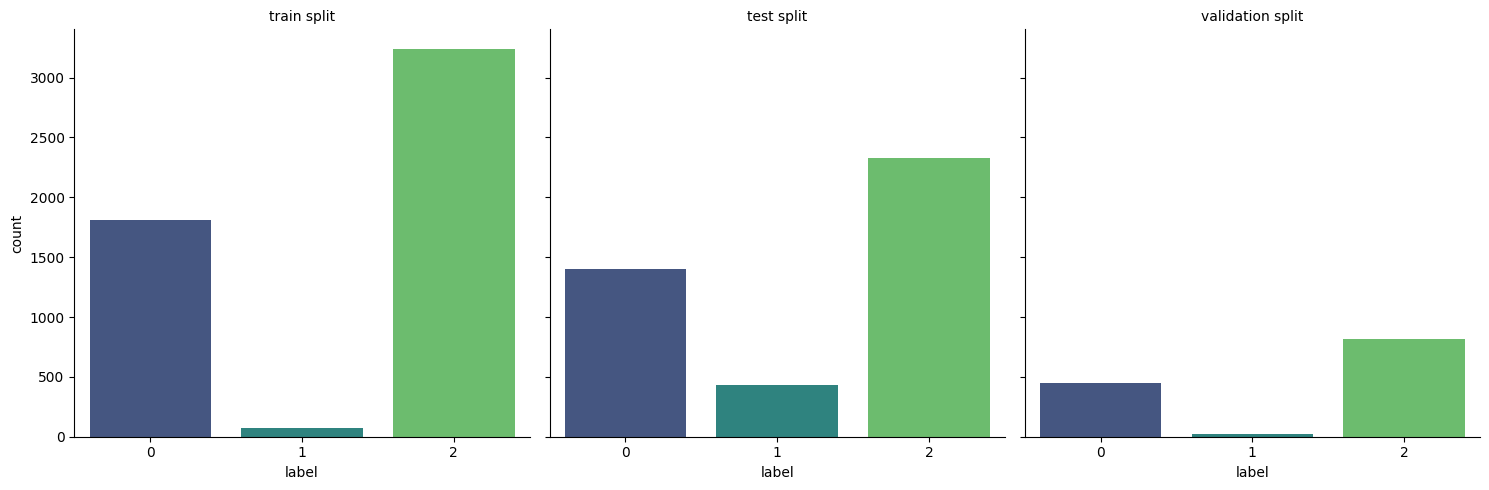

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crée une grille de 3 graphiques alignés horizontalement
g = sns.catplot(
    data=df, 
    x='label', 
    col='split',       # Crée un graphique par valeur unique de 'split'
    kind='count',      # Spécifie qu'il s'agit d'un countplot
    palette='viridis',
    col_order=['train', 'test', 'validation'] # Force l'ordre des graphiques
)

# Ajuste les titres des axes pour chaque graphique
g.set_titles("{col_name} split")
plt.show()


In [18]:
import pandas as pd

In [ ]:
# 1. Définir précisément la taille voulue pour chaque couple (split, label)
configuration = {
    ("test", 1): 1500,  # 100 lignes pour test avec label 1
    ("test", 0): 900,  # 200 lignes pour test avec label 2
    ("train",1): 3108,
    ("train",0): 1200,
    ("validation", 1): 763,  # Exemple : 10 lignes pour train avec label 1
    ("validation", 0): 400,  # Exemple : 50 lignes pour val avec label 1
}

# 2. Filtrer et combiner selon la configuration
df_amh_to_back = pd.concat(
    [
        df_amh[(df_amh["split"] == cat) & (df_amh["label"] == lab)].head(taille)
        for (cat, lab), taille in configuration.items()
    ]
).reset_index(drop=True)

df_amh_to_back = df_amh_to_back.head(100)

In [ ]:
df_amh_to_back

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import Dataset
import pandas as pd

def back_translate_dataset():
    # 1. Configuration du modèle et du tokenizer
    model_name = "facebook/nllb-200-distilled-600M"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    # 2. Préparation de votre dataset
    # (Remplacez cette partie par le chargement de votre fichier, ex: Dataset.from_pandas(pd.read_csv("data.csv")))

    dataset = Dataset.from_pandas(df_amh_to_back)
    
    # 3. Codes de langue NLLB
    lang_src = "amh_Ethi" # Amharic
    lang_tgt = "pcm_Latn" # pidding english

    # 4. Fonction de traitement par lot (Batch Processing)
    def process_batch(batch):
        # --- ÉTAPE 1 : TRADUCTION ALLER  ---
        tokenizer.src_lang = lang_src
        inputs_aller = tokenizer(batch["tweet"], padding=True, truncation=True, return_tensors="pt").to(device)
        
        tokens_aller = model.generate(
            **inputs_aller,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(lang_tgt),
            max_length=128
        )
        textes_intermediaires = tokenizer.batch_decode(tokens_aller, skip_special_tokens=True)
        
        # --- ÉTAPE 2 : TRADUCTION RETOUR ---
        tokenizer.src_lang = lang_tgt
        inputs_retour = tokenizer(textes_intermediaires, padding=True, truncation=True, return_tensors="pt").to(device)
        
        tokens_retour = model.generate(
            **inputs_retour,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(lang_src),
            max_length=128
        )
        textes_finals = tokenizer.batch_decode(tokens_retour, skip_special_tokens=True)
        
        # On retourne les nouvelles colonnes à ajouter au dataset
        return {
            "texte_intermediaire": textes_intermediaires,
            "back_translated": textes_finals
        }

    # 5. Application de la fonction sur tout le dataset
    # batched=True permet de traiter les phrases par groupes (ici 2 par 2 pour l'exemple)
    print("Début de la back-translation du dataset...")
    dataset_augmente = dataset.map(process_batch, batched=True, batch_size=2)
    
    # 6. Conversion et affichage/sauvegarde du résultat
    df_resultat = dataset_augmente.to_pandas()
    print("\n--- Résultat Final ---")
    #print(df_resultat[["texte_original", "back_translated"]])
    
    # Sauvegarde au format CSV
    df_resultat.to_csv("dataset_back_translated.csv", index=False)
    print("\nDataset sauvegardé sous 'dataset_back_translated.csv'")

if __name__ == "__main__":
    back_translate_dataset()


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Début de la back-translation du dataset...


Map:   0%|          | 0/100 [00:00<?, ? examples/s]


--- Résultat Final ---

Dataset sauvegardé sous 'dataset_back_translated.csv'
